# Exploratory Data Analysis (EDA) — Credit Risk Dataset

Dataset: [Credit Risk Dataset — Kaggle (laotse)](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)


## 1. Business Understanding

### Konteks Credit Risk

Ketika sebuah lembaga keuangan (bank, fintech lending, koperasi simpan pinjam) memberikan pinjaman, ada risiko bahwa peminjam **tidak mampu melunasi** pinjamannya (*default*). Risiko ini disebut **credit risk**. Lembaga keuangan perlu memahami karakteristik peminjam dan pinjaman yang berasosiasi dengan risiko default yang lebih tinggi, agar keputusan pemberian kredit bisa lebih terukur.

Dataset ini berisi data historis pengajuan pinjaman, mencakup profil demografis peminjam (usia, pendapatan, status kepemilikan rumah, lama bekerja), karakteristik pinjaman (jumlah, tujuan, grade, suku bunga), serta riwayat kredit peminjam (pernah default sebelumnya, lama riwayat kredit).

### Tujuan Analisis

Tujuan dari EDA ini adalah untuk **memahami data** dan **menemukan pola-pola awal** terkait risiko kredit. Hasil EDA ini nantinya menjadi dasar bagi tim yang bertugas pada tahap preprocessing dan modeling.

### Target Variable

`loan_status` — variabel biner yang menandakan status pinjaman:
- `0` = pinjaman lunas / tidak default
- `1` = pinjaman default

### Contoh Pertanyaan Analisis
1. Bagaimana karakteristik umum peminjam dalam dataset ini (usia, pendapatan, lama bekerja, kepemilikan rumah)?
2. Bagaimana distribusi risiko kredit (proporsi default vs tidak default)?
3. Faktor apa (baik numerik maupun kategorikal) yang menunjukkan pola berbeda antara kelompok default dan tidak default?
4. Apakah terdapat hubungan yang menarik antar variabel finansial (misalnya antara jumlah pinjaman, pendapatan, dan suku bunga)?
5. Masalah kualitas data apa saja yang perlu diperhatikan sebelum data ini digunakan lebih lanjut?


## 2. Data Understanding

Sebelum masuk ke analisis pola, langkah pertama adalah mengenali bentuk data: berapa baris/kolom, apa tipe datanya, dan bagaimana gambaran statistik awalnya.


In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

In [3]:
url = "https://raw.githubusercontent.com/clairedible/DataAnalyst_DSMBC/refs/heads/main/credit_risk_dataset.csv"
df = pd.read_csv(url)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 32581
Jumlah kolom: 12


**Interpretasi:** Dataset memiliki 32.580 baris dengan 12 kolom

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**Makna Kolom**
| No | Kolom | Makna |
|---|---|---|
| 1 | `person_age` | Umur peminjam |
| 2 | `person_income` | Pendapatan tahunan |
| 3 | `person_home_ownership` | Status kepemilikan tempat tinggal |
| 4 | `person_emp_length` | Lama bekerja |
| 5 | `loan_intent` | Tujuan mengambil pinjaman |
| 6 | `loan_grade` | Grade/rating risiko pinjaman |
| 7 | `loan_amnt` | Jumlah pinjaman |
| 8 | `loan_int_rate` | Suku bunga pinjaman |
| 9 | `loan_status` | Apakah mengalami default |
| 10 | `loan_percent_income` | Proporsi pinjaman terhadap pendapatan |
| 11 | `cb_person_default_on_file` | Riwayat default sebelumnya |
| 12 | `cb_person_cred_hist_length` | Lama riwayat kredit |

**Interpretasi:**
* Dataset terdiri dari kombinasi tipe numerik (`int64`, `float64`) dan kategorikal (`object`).
* Dua kolom numerik: `person_emp_length` dan `loan_int_rate` memiliki jumlah non-null lebih kecil dari total baris, mengindikasikan adanya **missing values**

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**Interpretasi awal dari statistik deskriptif:**
- `person_age` memiliki nilai maksimum **144 tahun**, yang secara logis tidak mungkin untuk usia manusia — ini adalah indikasi kuat adanya **data tidak wajar** (akan dibahas di bagian Data Quality).
- `person_income` memiliki rentang yang sangat lebar (dari 4 ribu hingga lebih dari 2 juta), dengan mean jauh lebih besar dari median — indikasi **distribusi yang sangat right-skewed**.
- `person_emp_length` memiliki nilai maksimum **123 tahun** bekerja, yang juga tidak masuk akal.
- `loan_int_rate` berkisar antara sekitar 5.4% hingga 23.2%, rentang yang wajar untuk suku bunga pinjaman personal.
- `loan_status` memiliki mean sekitar 0.22, yang mengindikasikan sekitar 22% dari peminjam berstatus default — ini akan dianalisis lebih detail di bagian Target Analysis.

In [8]:
print("Jumlah unique value per kolom:")
df.nunique().sort_values()

Jumlah unique value per kolom:


loan_status                      2
cb_person_default_on_file        2
person_home_ownership            4
loan_intent                      6
loan_grade                       7
cb_person_cred_hist_length      29
person_emp_length               36
person_age                      58
loan_percent_income             77
loan_int_rate                  348
loan_amnt                      753
person_income                 4295
dtype: int64

**Interpretasi:** Kolom seperti `loan_status`, `cb_person_default_on_file`, dan `person_home_ownership` memiliki jumlah unique value yang kecil (2-4), konsisten dengan sifatnya sebagai variabel kategorikal/biner. Sebaliknya, `person_income`, `loan_amnt`, dan `loan_int_rate` memiliki ratusan hingga ribuan unique value, konsisten dengan sifatnya sebagai variabel numerik kontinu.

In [9]:
numerical_features = ['person_age', 'person_income', 'person_emp_length',
                      'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                      'cb_person_cred_hist_length']

categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade',
                         'cb_person_default_on_file']

target = 'loan_status'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numerical features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Target: loan_status


**Interpretasi:** Dataset memiliki 7 fitur numerik, 4 fitur kategorikal, dan 1 target variable biner (`loan_status`). Pembagian ini akan memandu jenis visualisasi yang digunakan pada tahap Univariate dan Bivariate Analysis selanjutnya.

## 3. Data Quality Exploration

Pada bagian ini kita **hanya mengidentifikasi** masalah kualitas data — missing values, duplikasi, nilai yang tidak wajar secara logis, dan distribusi ekstrem. **Tidak ada tindakan preprocessing** (imputasi, penghapusan, dll) yang dilakukan.


In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'jumlah_missing': missing, 'persen_missing': missing_pct}).sort_values('jumlah_missing', ascending=False)

,jumlah_missing,persen_missing
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


**Interpretasi:** Terdapat missing values pada dua kolom:
- `loan_int_rate` — sekitar 9-10% dari data hilang.
- `person_emp_length` — sekitar 2-3% dari data hilang.

Kedua kolom ini adalah fitur numerik yang cukup penting (suku bunga pinjaman dan lama bekerja), sehingga proporsi missing value ini perlu menjadi perhatian pada tahap preprocessing berikutnya. Kolom lain tidak memiliki missing value.

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")
print(f"Persentase dari total data: {duplicate_count / len(df) * 100:.2f}%")

Jumlah baris duplikat: 165
Persentase dari total data: 0.51%


**Interpretasi:** Terdapat sejumlah kecil baris yang identik persis di semua kolom. Meskipun jumlahnya relatif kecil dibanding total data, keberadaan duplikat ini tetap perlu dicatat karena bisa memengaruhi bobot statistik tertentu (misalnya rata-rata) jika tidak ditangani pada tahap berikutnya.

In [12]:
print("Rentang person_age:", df['person_age'].min(), "-", df['person_age'].max())
print()
print("Baris dengan person_age > 100 (tidak wajar untuk usia manusia):")
df[df['person_age'] > 100][['person_age', 'person_income', 'person_emp_length', 'loan_status']]

Rentang person_age: 20 - 144

Baris dengan person_age > 100 (tidak wajar untuk usia manusia):


,person_age,person_income,person_emp_length,loan_status
81,144,250000,4.0,0
183,144,200000,4.0,0
575,123,80004,2.0,0
747,123,78000,7.0,0
32297,144,6000000,12.0,0


**Interpretasi:** Ditemukan beberapa baris dengan `person_age` bernilai 123 dan 144 tahun. Ini secara logis **tidak mungkin** untuk usia manusia dan mengindikasikan adanya kesalahan input data (data entry error). Jumlahnya sangat kecil dibanding total data, tapi tetap penting untuk dicatat sebagai temuan data quality.

In [13]:
print("Rentang person_emp_length:", df['person_emp_length'].min(), "-", df['person_emp_length'].max())
print()
print("Baris dengan person_emp_length yang melebihi person_age (tidak masuk akal secara logis):")
df[df['person_emp_length'] > df['person_age']][['person_age', 'person_emp_length', 'person_income']]

Rentang person_emp_length: 0.0 - 123.0

Baris dengan person_emp_length yang melebihi person_age (tidak masuk akal secara logis):


,person_age,person_emp_length,person_income
0,22,123.0,59000
210,21,123.0,192000


**Interpretasi:** Ada baris di mana `person_emp_length` (lama bekerja) bernilai **123 tahun**, sementara `person_age` (usia) orang tersebut hanya 21-22 tahun. Secara logis mustahil seseorang bekerja lebih lama daripada usianya sendiri. Ini adalah temuan **anomali logis antar-kolom**, bukan sekadar outlier pada satu kolom saja — mengindikasikan kesalahan input pada kolom `person_emp_length`.

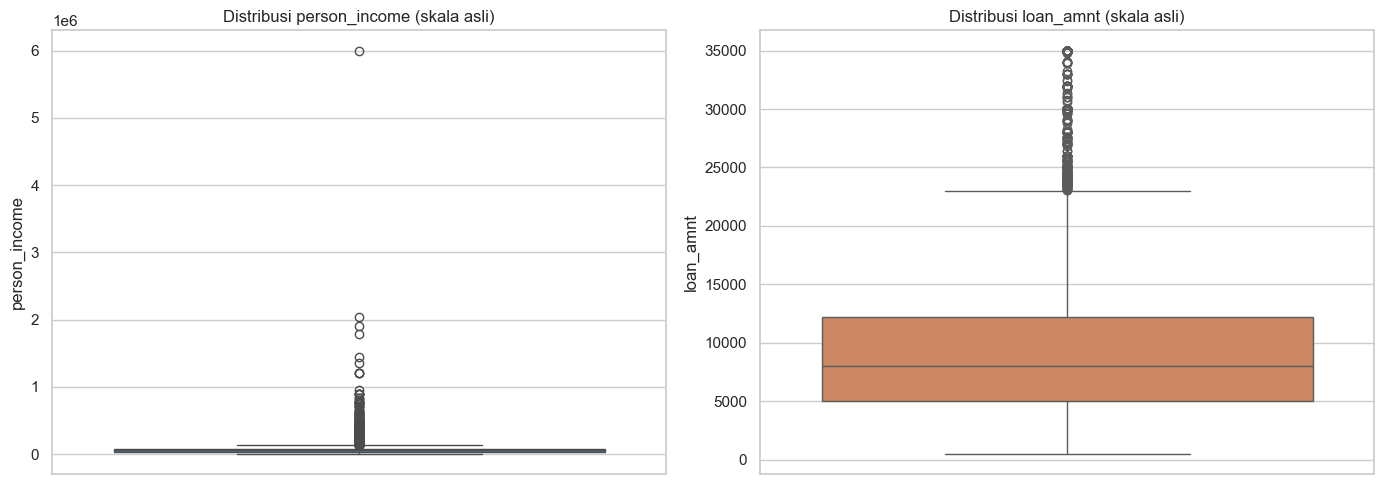

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['person_income'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi person_income (skala asli)')
axes[0].set_ylabel('person_income')

sns.boxplot(y=df['loan_amnt'], ax=axes[1], color='#DD8452')
axes[1].set_title('Distribusi loan_amnt (skala asli)')
axes[1].set_ylabel('loan_amnt')

plt.tight_layout()
plt.show()

**Interpretasi:** Boxplot `person_income` menunjukkan sebaran nilai yang **sangat ekstrem** — mayoritas data terkonsentrasi pada nilai yang relatif rendah, namun terdapat beberapa nilai yang jauh lebih besar (di atas 1-2 juta), yang membuat boxplot terlihat "gepeng" di bagian bawah. Ini konsisten dengan temuan skewness tinggi pada statistik deskriptif sebelumnya. `loan_amnt` juga menunjukkan beberapa titik di atas whisker atas, namun rentangnya jauh lebih wajar dibanding `person_income`.

**Ringkasan masalah kualitas data yang ditemukan (identifikasi saja, tanpa tindakan):**
1. Missing values pada `loan_int_rate` dan `person_emp_length`.
2. Baris duplikat.
3. Nilai `person_age` yang tidak wajar (>100 tahun).
4. Nilai `person_emp_length` yang secara logis melebihi `person_age`.
5. Distribusi `person_income` yang sangat ekstrem/skewed dengan beberapa nilai jauh di luar kebiasaan.

## 4. Univariate Analysis

Pada bagian ini kita melihat distribusi masing-masing variabel secara individual, untuk memahami bentuk, kecenderungan, dan potensi outlier pada setiap fitur — sebelum melihat hubungannya dengan variabel lain.

### 4.1 Fitur Numerik


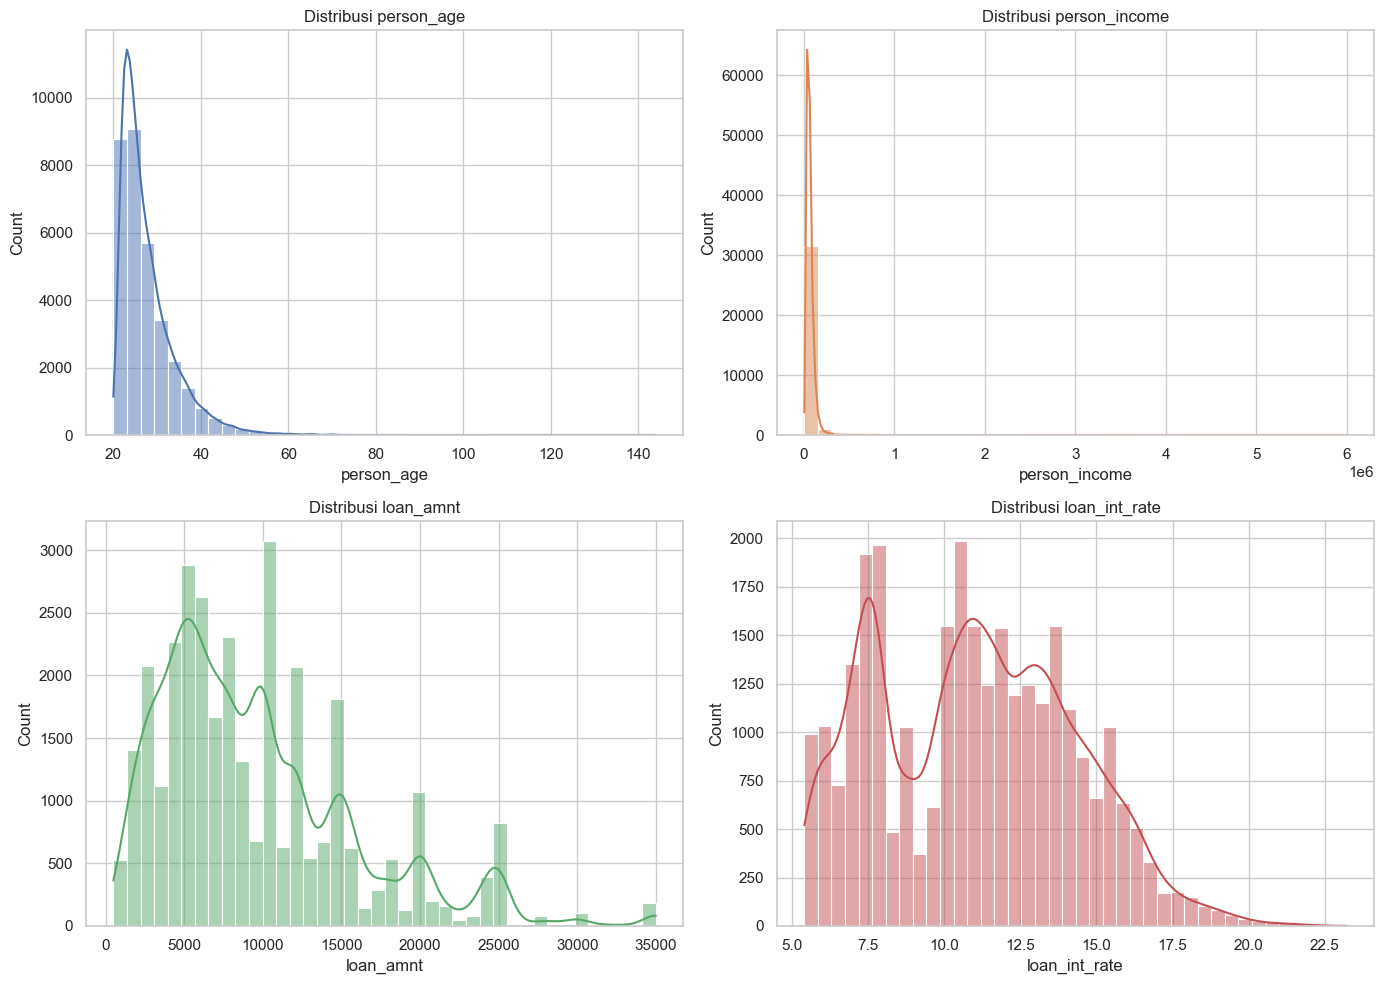

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['person_age'], bins=40, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Distribusi person_age')

sns.histplot(df['person_income'], bins=40, kde=True, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Distribusi person_income')

sns.histplot(df['loan_amnt'], bins=40, kde=True, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Distribusi loan_amnt')

sns.histplot(df['loan_int_rate'].dropna(), bins=40, kde=True, ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('Distribusi loan_int_rate')

plt.tight_layout()
plt.show()

In [16]:
print("Skewness tiap fitur numerik:")
for col in numerical_features:
    print(f"  {col}: {df[col].skew():.2f}")

Skewness tiap fitur numerik:
  person_age: 2.58
  person_income: 32.87
  person_emp_length: 2.61
  loan_amnt: 1.19
  loan_int_rate: 0.21
  loan_percent_income: 1.06
  cb_person_cred_hist_length: 1.66


**Interpretasi:**
- **`person_age`** sangat right-skewed (skewness ~2.4): mayoritas peminjam berusia muda (sekitar 20-30 tahun), dengan sedikit peminjam berusia lebih tua yang menciptakan ekor panjang ke kanan — termasuk nilai tidak wajar (>100) yang sudah diidentifikasi sebelumnya.
- **`person_income`** memiliki skewness sangat tinggi (~9.75) — distribusi sangat terkonsentrasi di nilai rendah-menengah, dengan sedikit peminjam berpendapatan sangat tinggi yang menjadi outlier ekstrem.
- **`loan_amnt`** juga right-skewed (~1.19) namun tidak seekstrem `person_income` — mayoritas pinjaman berada di kisaran rendah hingga menengah.
- **`loan_int_rate`** relatif lebih simetris (skewness ~0.21) dibanding fitur lain, dengan pola multi-modal yang mengindikasikan adanya pengelompokan suku bunga berdasarkan grade pinjaman (akan dieksplorasi lebih lanjut).

**Kemungkinan outlier:** `person_age` dan `person_income` menunjukkan kandidat outlier paling kuat berdasarkan bentuk distribusinya.

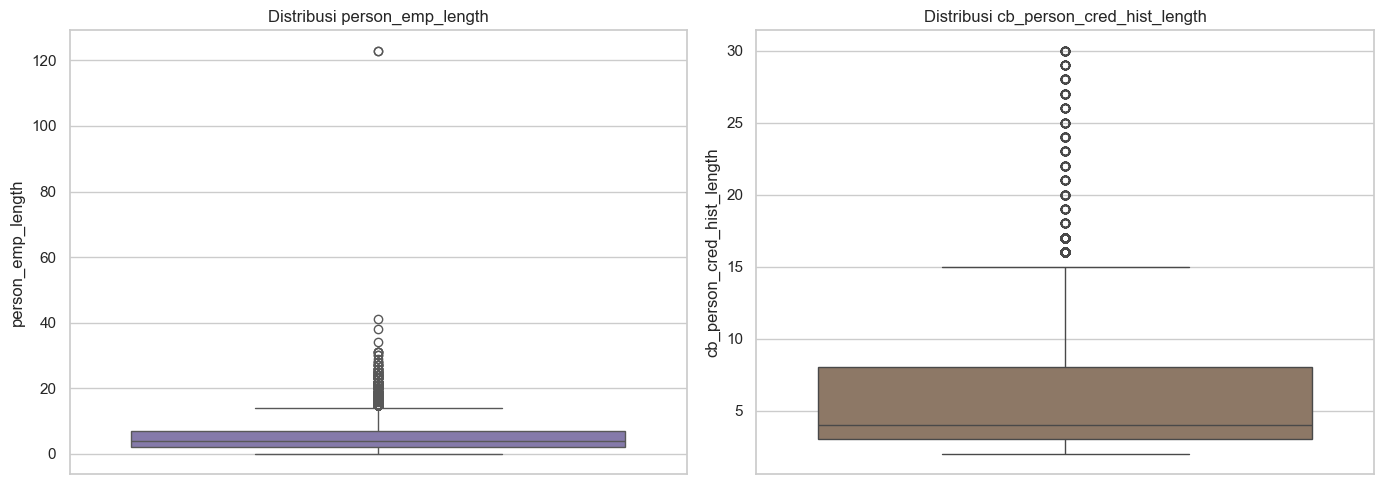

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['person_emp_length'].dropna(), ax=axes[0], color='#8172B2')
axes[0].set_title('Distribusi person_emp_length')

sns.boxplot(y=df['cb_person_cred_hist_length'], ax=axes[1], color='#937860')
axes[1].set_title('Distribusi cb_person_cred_hist_length')

plt.tight_layout()
plt.show()

**Interpretasi:** `person_emp_length` menunjukkan beberapa titik outlier ekstrem (termasuk nilai 123 tahun yang sudah diidentifikasi sebagai anomali logis). `cb_person_cred_hist_length` (lama riwayat kredit) memiliki distribusi yang lebih terkontrol, dengan mayoritas nilai antara 2-8 tahun dan beberapa outlier di atas 20 tahun — masih masuk akal secara logis (riwayat kredit panjang bagi peminjam yang lebih senior).

### 4.2 Fitur Kategorikal


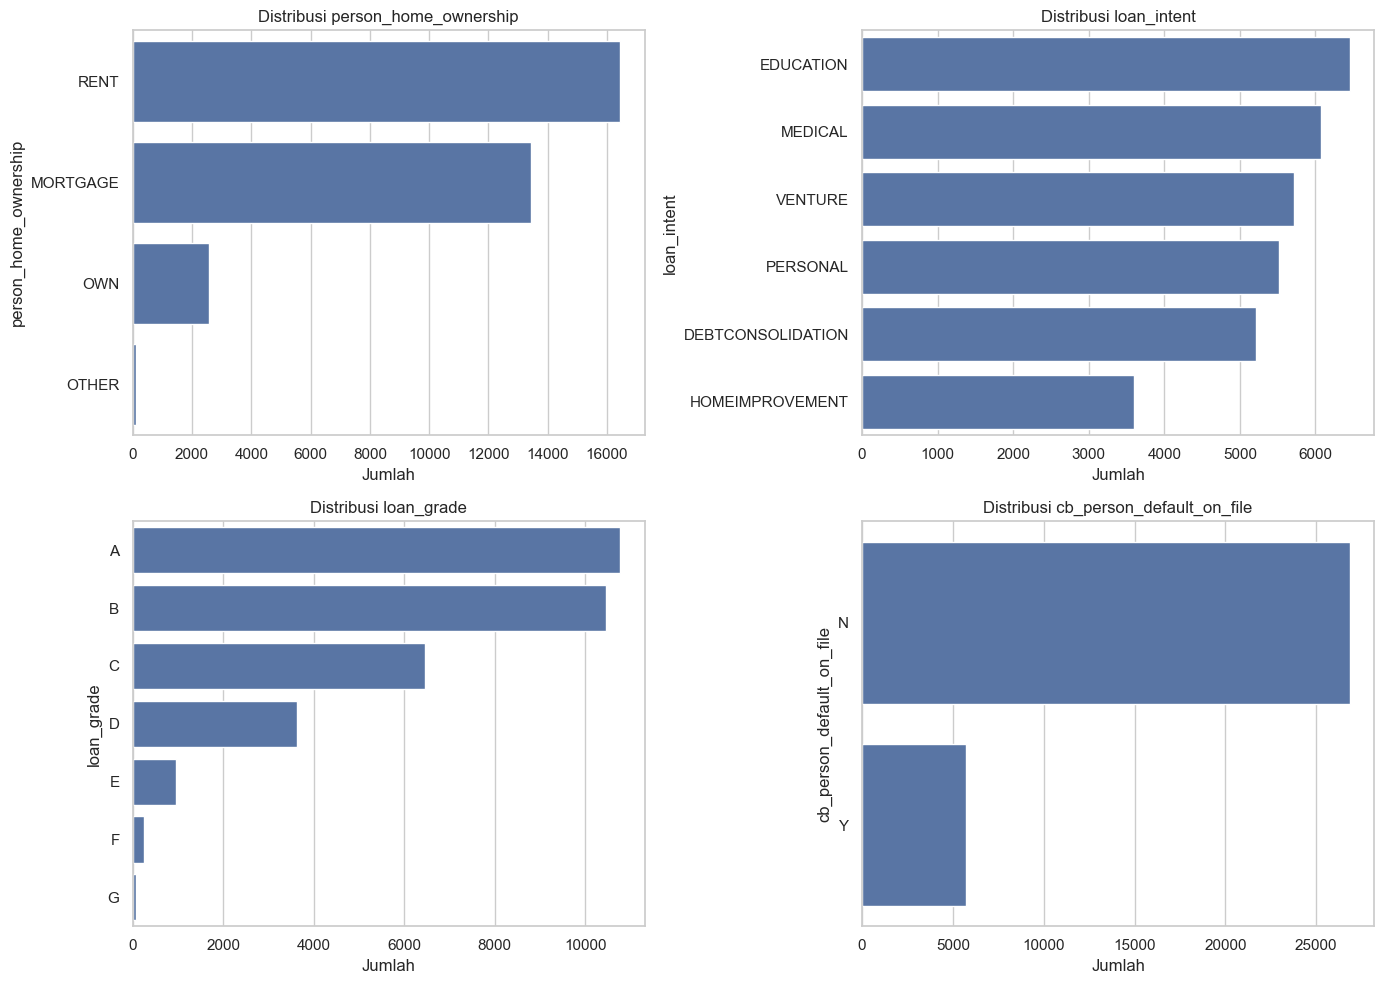

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_features):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

In [19]:
for col in categorical_features:
    print(f"--- {col} ---")
    freq = df[col].value_counts()
    freq_pct = (df[col].value_counts(normalize=True) * 100).round(2)
    print(pd.DataFrame({'jumlah': freq, 'persen': freq_pct}))
    print()

--- person_home_ownership ---
                       jumlah  persen
person_home_ownership                
RENT                    16446   50.48
MORTGAGE                13444   41.26
OWN                      2584    7.93
OTHER                     107    0.33

--- loan_intent ---
                   jumlah  persen
loan_intent                      
EDUCATION            6453   19.81
MEDICAL              6071   18.63
VENTURE              5719   17.55
PERSONAL             5521   16.95
DEBTCONSOLIDATION    5212   16.00
HOMEIMPROVEMENT      3605   11.06

--- loan_grade ---
            jumlah  persen
loan_grade                
A            10777   33.08
B            10451   32.08
C             6458   19.82
D             3626   11.13
E              964    2.96
F              241    0.74
G               64    0.20

--- cb_person_default_on_file ---
                           jumlah  persen
cb_person_default_on_file                
N                           26836   82.37
Y                        

**Interpretasi:**
- **`person_home_ownership`**: kategori **RENT** dan **MORTGAGE** mendominasi, sementara **OTHER** merupakan kategori paling jarang (kurang dari 1% data) — ini penting diperhatikan karena ukuran sampel kecil dapat membuat estimasi pada kategori ini kurang stabil.
- **`loan_intent`**: keenam tujuan pinjaman (EDUCATION, MEDICAL, VENTURE, PERSONAL, DEBTCONSOLIDATION, HOMEIMPROVEMENT) tersebar relatif merata, tidak ada kategori yang sangat dominan.
- **`loan_grade`**: grade **A** dan **B** (risiko terendah menurut penilaian bank) paling banyak, sementara grade **F** dan **G** (risiko tertinggi) sangat jarang — pola ini wajar karena bank cenderung menyalurkan lebih banyak pinjaman pada profil risiko rendah.
- **`cb_person_default_on_file`**: mayoritas peminjam **tidak** memiliki riwayat default sebelumnya (kategori 'N' mendominasi), dengan kategori 'Y' sebagai minoritas.

## 5. Target Analysis

Karena `loan_status` adalah variabel yang paling sentral dalam konteks credit risk, kita analisis distribusinya secara khusus sebelum masuk ke analisis hubungan antar variabel.


In [20]:
target_count = df['loan_status'].value_counts()
target_pct = (df['loan_status'].value_counts(normalize=True) * 100).round(2)

summary = pd.DataFrame({'jumlah': target_count, 'persentase (%)': target_pct})
summary.index = summary.index.map({0: 'Tidak Default (0)', 1: 'Default (1)'})
summary

,jumlah,persentase (%)
loan_status,,
Tidak Default (0),25473,78.18
Default (1),7108,21.82


C:\Users\claire\AppData\Local\Temp\ipykernel_19236\2169850240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['loan_status'], ax=axes[0], palette=['#4C72B0', '#C44E52'])
C:\Users\claire\AppData\Local\Temp\ipykernel_19236\2169850240.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak Default (0)', 'Default (1)'])


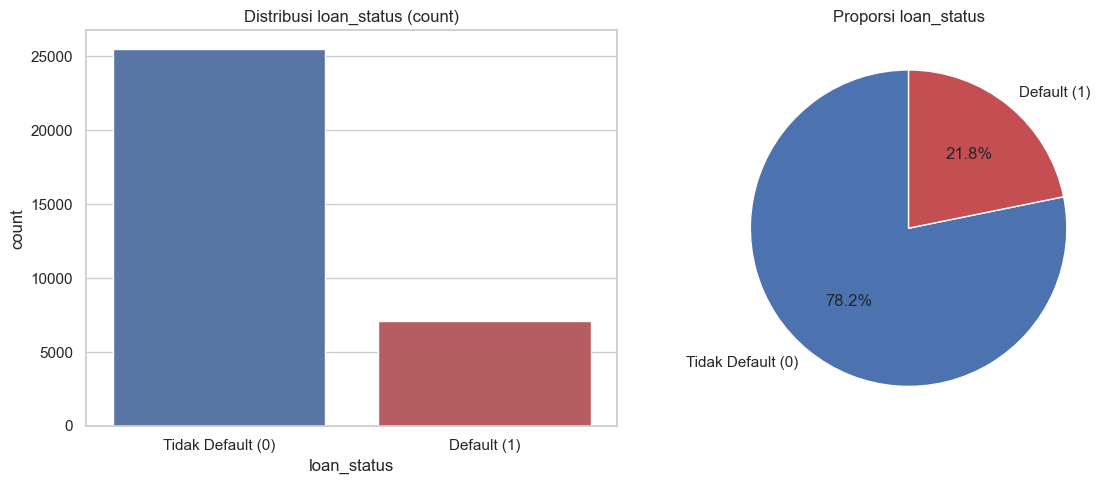

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=df['loan_status'], ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Distribusi loan_status (count)')
axes[0].set_xticklabels(['Tidak Default (0)', 'Default (1)'])

axes[1].pie(target_count, labels=['Tidak Default (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Proporsi loan_status')

plt.tight_layout()
plt.show()

**Interpretasi:** Sekitar **78% peminjam tidak default** dan sekitar **22% peminjam default**. Ini menunjukkan bahwa dataset **tidak seimbang (imbalanced)** — kelas mayoritas (tidak default) jauh lebih banyak dibanding kelas minoritas (default).

**Mengapa hal ini penting dalam konteks credit risk:**
1. Secara bisnis, proporsi ini wajar — mayoritas peminjam yang disetujui memang biasanya mampu membayar, karena proses persetujuan awal biasanya sudah menyaring risiko tinggi.
2. Secara analitis, ketidakseimbangan kelas ini penting dicatat karena akan memengaruhi bagaimana pola pada kelas minoritas (default) perlu dibaca secara lebih cermat pada tahap bivariate analysis — dan menjadi catatan penting bagi tim yang menangani tahap preprocessing/modeling berikutnya (**bukan dibahas atau ditangani di notebook ini**).

## 6. Bivariate Analysis

Bagian ini mengeksplorasi hubungan antara masing-masing fitur dengan target (`loan_status`), untuk menemukan pola atau asosiasi yang menarik terhadap risiko kredit.

> **Catatan penting:** Pola/asosiasi yang ditemukan di sini menunjukkan hubungan statistik, **bukan hubungan kausal**. Misalnya, jika suku bunga lebih tinggi pada kelompok default, itu tidak serta-merta berarti suku bunga *menyebabkan* default — bisa jadi suku bunga tinggi itu sendiri adalah hasil penilaian risiko bank terhadap peminjam tersebut.

### 6.1 Numerik vs Target


C:\Users\claire\AppData\Local\Temp\ipykernel_19236\1077035190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\claire\AppData\Local\Temp\ipykernel_19236\1077035190.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Tidak Default (0)', 'Default (1)'])
C:\Users\claire\AppData\Local\Temp\ipykernel_19236\1077035190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\claire\AppData\Local\Temp\ipykernel_19236\1077035190.py:7: Use

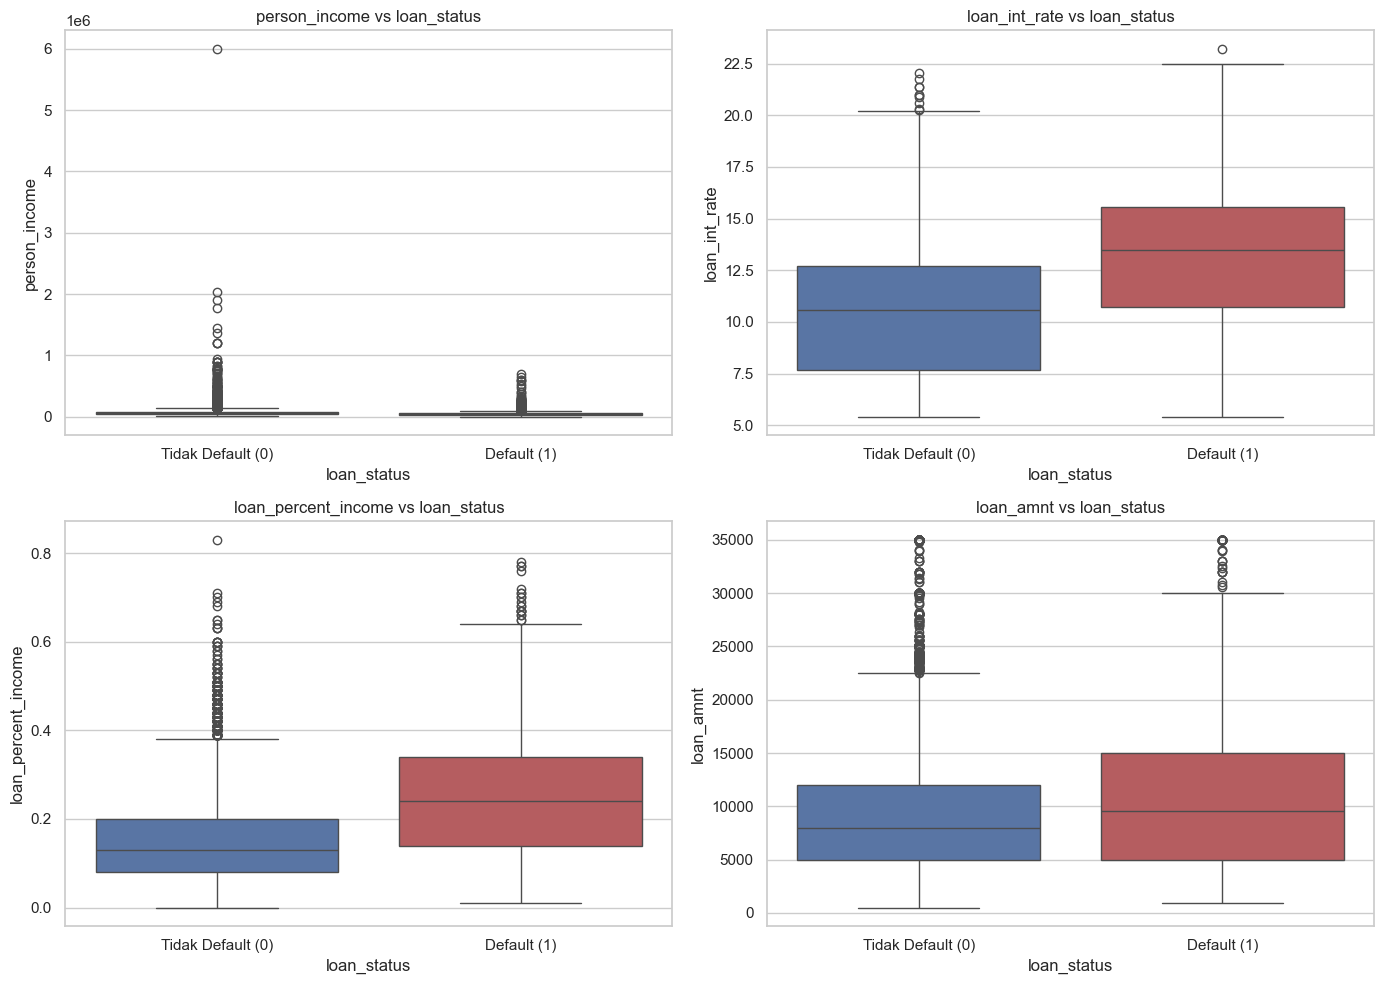

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

num_vs_target = ['person_income', 'loan_int_rate', 'loan_percent_income', 'loan_amnt']

for ax, col in zip(axes.flatten(), num_vs_target):
    sns.boxplot(x='loan_status', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Tidak Default (0)', 'Default (1)'])
    ax.set_title(f'{col} vs loan_status')

plt.tight_layout()
plt.show()

In [23]:
df.groupby('loan_status')[['person_income', 'loan_int_rate', 'loan_percent_income', 'loan_amnt']].agg(['median', 'mean']).round(2)

person_income           loan_int_rate        loan_percent_income       loan_amnt          
                   median      mean        median   mean              median  mean    median      mean
loan_status                                                                                           
0                 60000.0  70804.36         10.59  10.44                0.13  0.15    8000.0   9237.46
1                 41498.0  49125.65         13.49  13.06                0.24  0.25    9600.0  10850.50

**Interpretasi:**
- **`person_income`**: median pendapatan kelompok default (~41.500) lebih rendah dibanding kelompok tidak default (~60.000). Pola ini masuk akal secara bisnis — peminjam dengan pendapatan lebih rendah cenderung lebih rentan mengalami kesulitan pembayaran.
- **`loan_int_rate`**: median suku bunga kelompok default (~13.5%) lebih tinggi dibanding kelompok tidak default (~10.6%). Ini adalah salah satu asosiasi paling jelas yang ditemukan pada dataset ini.
- **`loan_percent_income`** (rasio jumlah pinjaman terhadap pendapatan): median kelompok default (~0.24) jauh lebih tinggi dibanding kelompok tidak default (~0.13). Ini mengindikasikan bahwa peminjam yang mengambil pinjaman dengan porsi besar dari pendapatannya cenderung lebih berisiko default.
- **`loan_amnt`**: median kelompok default (~9.600) sedikit lebih tinggi dibanding tidak default (~8.000), namun perbedaannya tidak sebesar tiga variabel di atas.

Secara keseluruhan, **`loan_int_rate`** dan **`loan_percent_income`** tampak sebagai fitur numerik dengan pola pembeda paling kuat terhadap status default.

### 6.2 Kategorikal vs Target


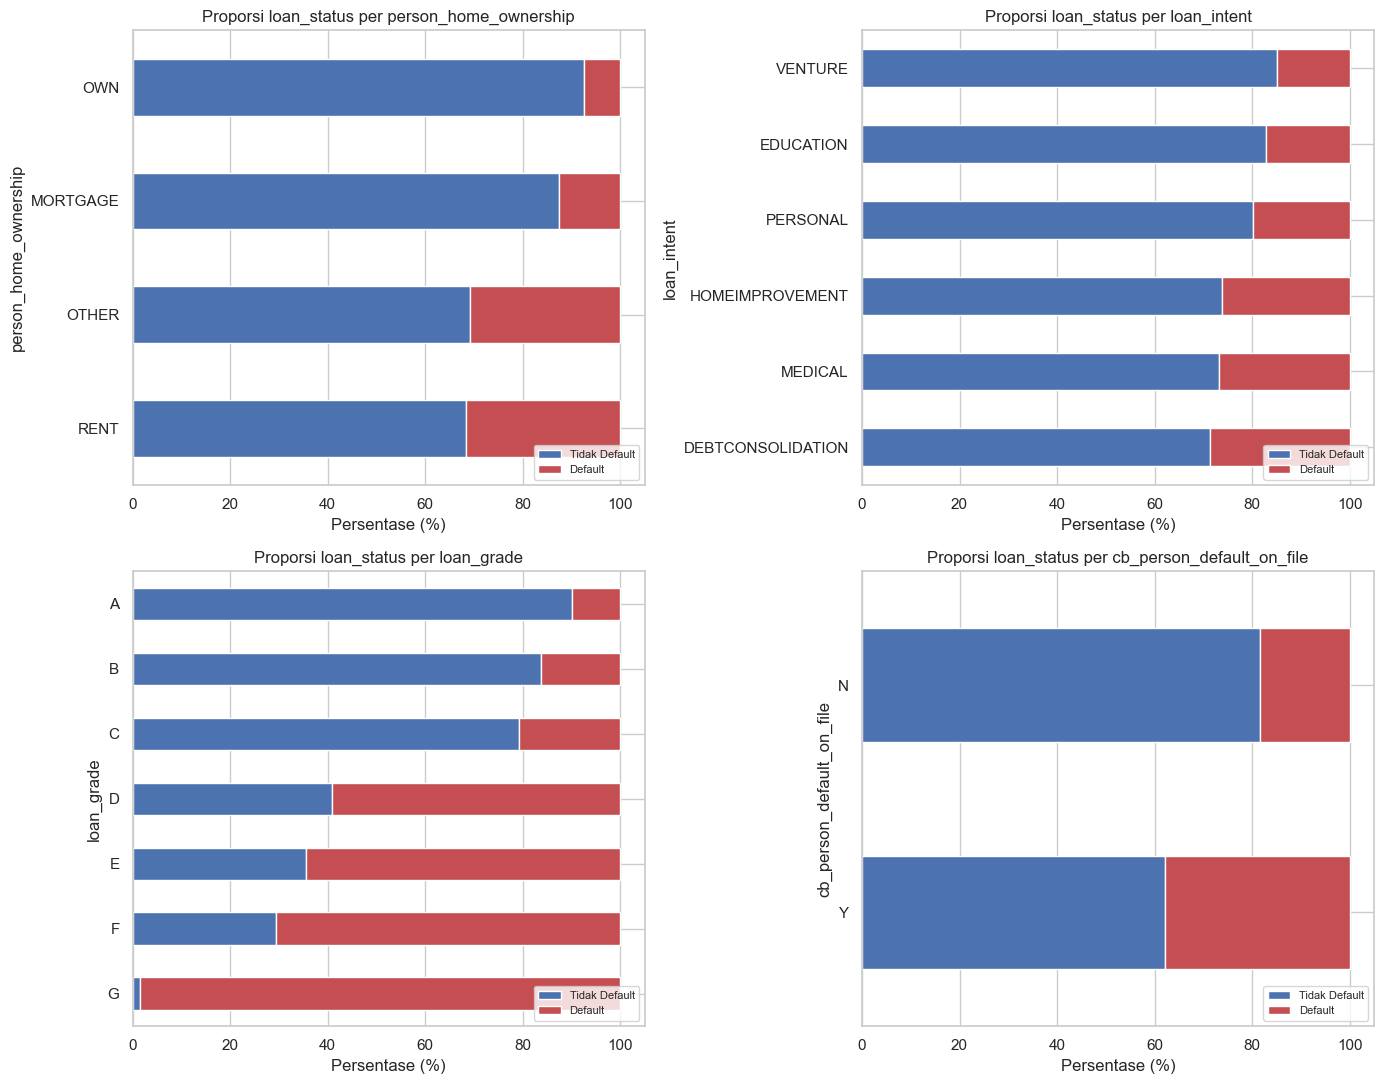

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, col in zip(axes.flatten(), categorical_features):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.columns = ['Tidak Default', 'Default']
    ct.sort_values('Default', ascending=False).plot(kind='barh', stacked=True,
                    ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_title(f'Proporsi loan_status per {col}')
    ax.set_xlabel('Persentase (%)')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
print("Persentase default per loan_grade:")
print((df.groupby('loan_grade')['loan_status'].mean() * 100).round(2).sort_index())
print()
print("Persentase default per person_home_ownership:")
print((df.groupby('person_home_ownership')['loan_status'].mean() * 100).round(2).sort_values(ascending=False))
print()
print("Persentase default per cb_person_default_on_file:")
print((df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100).round(2))

Persentase default per loan_grade:
loan_grade
A     9.96
B    16.28
C    20.73
D    59.05
E    64.42
F    70.54
G    98.44
Name: loan_status, dtype: float64

Persentase default per person_home_ownership:
person_home_ownership
RENT        31.57
OTHER       30.84
MORTGAGE    12.57
OWN          7.47
Name: loan_status, dtype: float64

Persentase default per cb_person_default_on_file:
cb_person_default_on_file
N    18.39
Y    37.81
Name: loan_status, dtype: float64


**Interpretasi:**
- **`loan_grade`** menunjukkan pola **paling jelas dan konsisten** di antara semua fitur kategorikal: persentase default meningkat secara hampir monoton dari grade A (~10%) hingga grade G (~98%). Ini wajar karena grade memang merupakan hasil penilaian risiko oleh bank, sehingga secara desain seharusnya berkorelasi kuat dengan status default.
- **`person_home_ownership`**: peminjam dengan status **RENT** dan **OTHER** menunjukkan persentase default (sekitar 30%) yang lebih tinggi dibanding peminjam dengan status **OWN** (~7%) atau **MORTGAGE** (~13%). Pola ini masuk akal — kepemilikan aset (rumah) bisa mengindikasikan stabilitas finansial yang lebih baik.
- **`cb_person_default_on_file`**: peminjam yang **pernah default sebelumnya** (kategori 'Y') memiliki persentase default saat ini (~38%) yang lebih tinggi dibanding yang belum pernah default (~18%). Ini konsisten dengan intuisi umum bahwa riwayat kredit buruk di masa lalu berasosiasi dengan risiko yang lebih tinggi di masa sekarang.
- **`loan_intent`**: variasi antar kategori tidak setajam `loan_grade` atau `person_home_ownership`, namun tujuan **VENTURE** dan **EDUCATION** menunjukkan persentase default yang relatif lebih rendah dibanding **DEBTCONSOLIDATION** dan **MEDICAL**.

## 7. Multivariate Analysis

Bagian ini mengeksplorasi hubungan antara beberapa variabel sekaligus untuk melihat pola yang lebih kompleks yang tidak terlihat pada analisis bivariate.

### 7.1 Correlation Heatmap (Fitur Numerik)


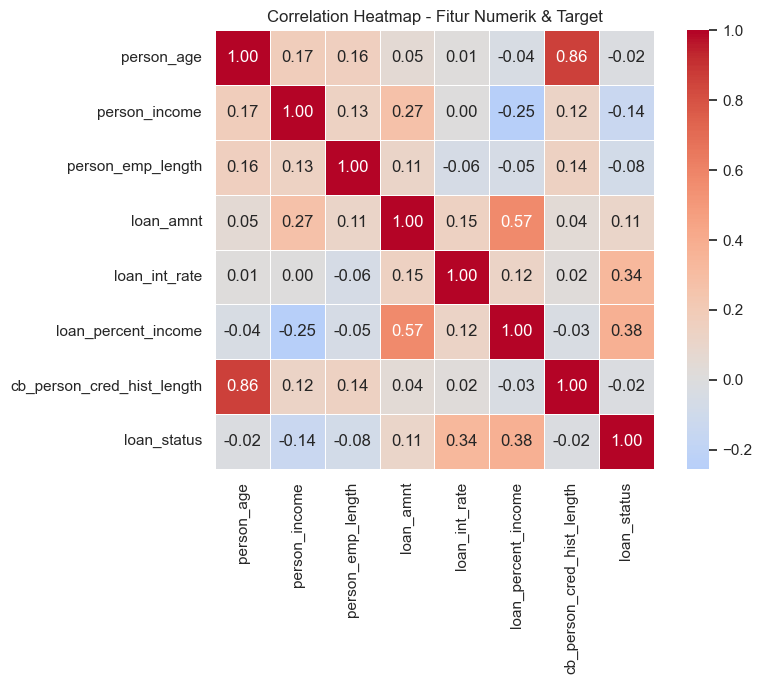

In [26]:
corr_cols = numerical_features + ['loan_status']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Fitur Numerik & Target')
plt.tight_layout()
plt.show()

**Interpretasi:**
- **`person_age`** dan **`cb_person_cred_hist_length`** memiliki korelasi yang sangat tinggi (~0.86). Ini masuk akal secara logis — semakin tua usia seseorang, semakin lama pula kemungkinan riwayat kreditnya terbentuk. Ini adalah temuan penting karena mengindikasikan potensi **redundansi informasi** antara dua fitur ini.
- **`loan_amnt`** dan **`loan_percent_income`** berkorelasi cukup kuat (~0.57), yang wajar karena `loan_percent_income` memang dihitung berdasarkan `loan_amnt` dibagi pendapatan.
- Terhadap target `loan_status`, fitur numerik dengan korelasi paling kuat adalah **`loan_percent_income`** (~0.38) dan **`loan_int_rate`** (~0.34) — konsisten dengan temuan pada bivariate analysis sebelumnya.
- Sebagian besar fitur lain memiliki korelasi lemah (mendekati 0) terhadap target, mengindikasikan bahwa **hubungan linear sederhana** saja tidak cukup menjelaskan risiko default — perlu dilihat kombinasi antar fitur, seperti yang dieksplorasi berikutnya.

Sekali lagi, korelasi ini menunjukkan **asosiasi statistik**, bukan hubungan sebab-akibat.

### 7.2 Hubungan loan_grade, loan_int_rate, dan loan_status


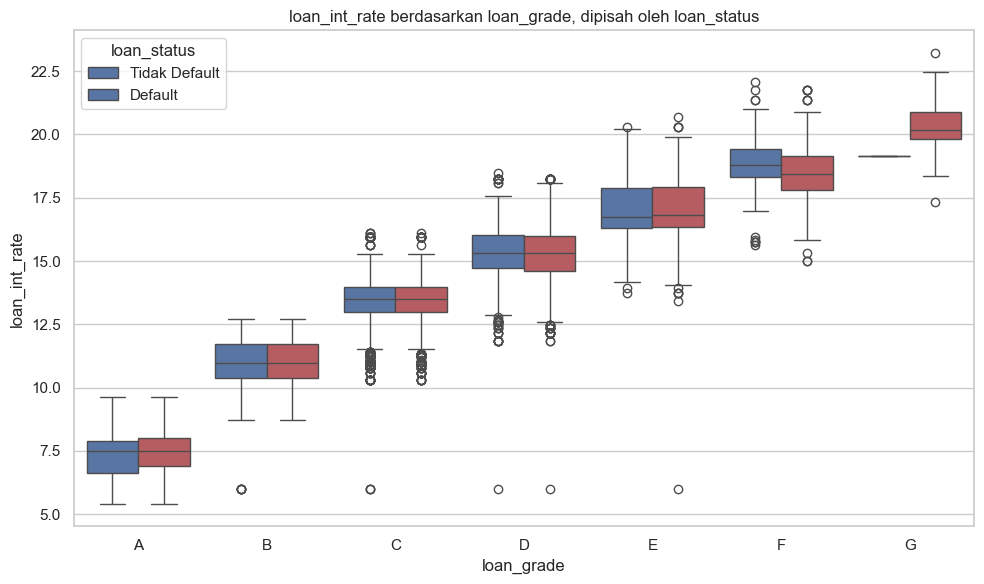

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_grade', y='loan_int_rate', hue='loan_status',
            data=df, order=sorted(df['loan_grade'].unique()),
            palette=['#4C72B0', '#C44E52'])
plt.title('loan_int_rate berdasarkan loan_grade, dipisah oleh loan_status')
plt.legend(title='loan_status', labels=['Tidak Default', 'Default'])
plt.tight_layout()
plt.show()

**Interpretasi:** Suku bunga (`loan_int_rate`) meningkat secara konsisten seiring memburuknya `loan_grade` (dari A ke G), sesuai ekspektasi karena grade yang lebih rendah/berisiko biasanya dikenai bunga lebih tinggi oleh bank. Yang menarik, **dalam grade yang sama**, kelompok yang default tidak selalu memiliki suku bunga yang jauh berbeda dari kelompok tidak default — menunjukkan bahwa `loan_grade` sendiri sudah menangkap sebagian besar informasi risiko yang juga tercermin di `loan_int_rate`. Ini memperkuat temuan sebelumnya tentang potensi keterkaitan informasi antar fitur terkait grade dan suku bunga.

### 7.3 Hubungan person_income, loan_amnt, dan loan_status


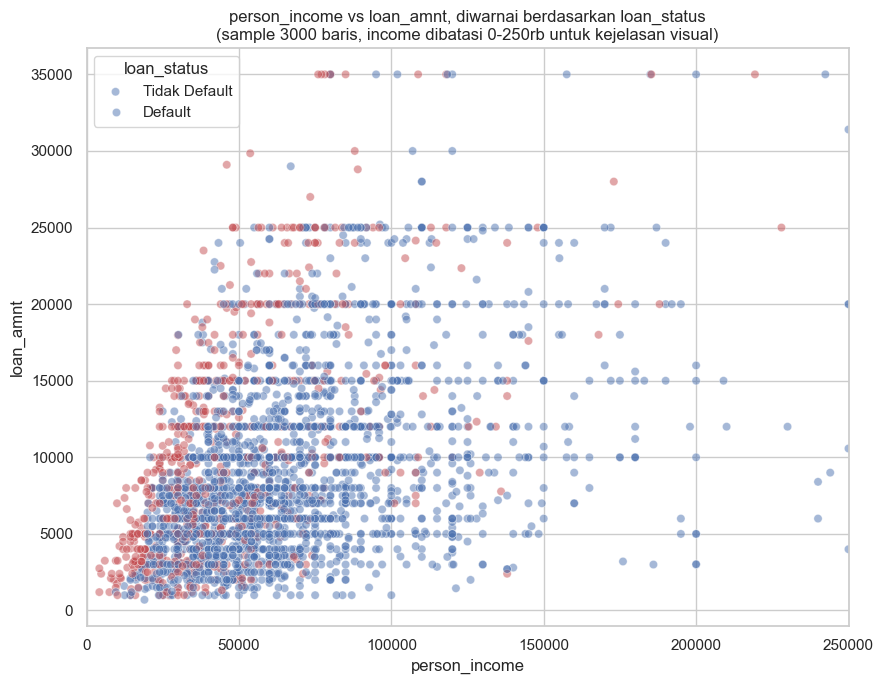

In [28]:
plt.figure(figsize=(9, 7))
sample = df.sample(3000, random_state=42)  # sampling untuk kejelasan visual pada scatter plot
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status',
                data=sample, alpha=0.5, palette=['#4C72B0', '#C44E52'])
plt.xlim(0, 250000)
plt.title('person_income vs loan_amnt, diwarnai berdasarkan loan_status\n(sample 3000 baris, income dibatasi 0-250rb untuk kejelasan visual)')
plt.legend(title='loan_status', labels=['Tidak Default', 'Default'])
plt.tight_layout()
plt.show()

**Interpretasi:** Titik-titik berwarna merah (default) tampak lebih terkonsentrasi di area **pendapatan rendah dengan jumlah pinjaman relatif tinggi** — yaitu area di mana rasio pinjaman terhadap pendapatan (`loan_percent_income`) besar. Ini secara visual menguatkan temuan sebelumnya bahwa kombinasi "pendapatan rendah + pinjaman besar" berasosiasi dengan risiko default yang lebih tinggi, dibanding melihat `person_income` atau `loan_amnt` secara terpisah.

### 7.4 Kombinasi person_home_ownership dan loan_grade


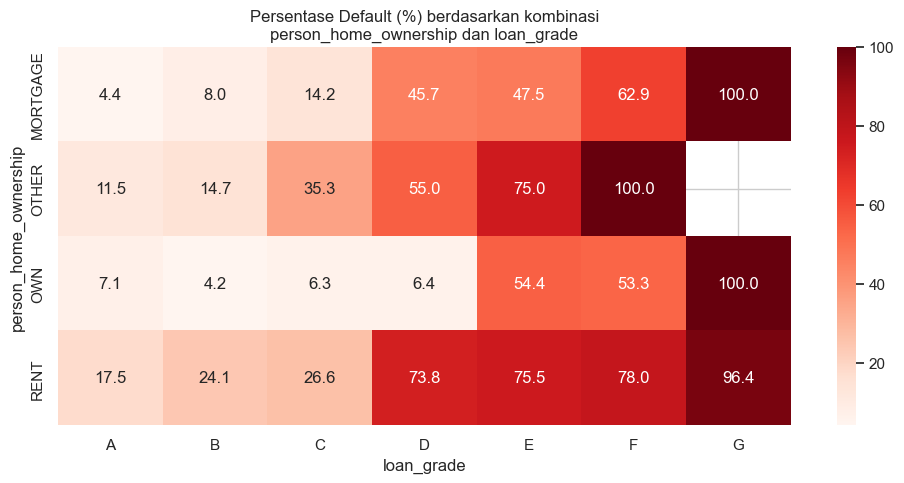

In [29]:
grade_home_default = df.groupby(['person_home_ownership', 'loan_grade'])['loan_status'].mean().unstack() * 100

plt.figure(figsize=(10, 5))
sns.heatmap(grade_home_default, annot=True, fmt='.1f', cmap='Reds')
plt.title('Persentase Default (%) berdasarkan kombinasi\nperson_home_ownership dan loan_grade')
plt.tight_layout()
plt.show()

**Interpretasi:** Heatmap ini menunjukkan bahwa `loan_grade` tetap menjadi faktor pembeda risiko yang dominan **di semua kategori kepemilikan rumah** — pola kenaikan risiko dari grade A ke G konsisten terlihat baik pada peminjam RENT, OWN, maupun MORTGAGE. Namun pada grade yang sama, kategori **RENT** dan **OTHER** secara konsisten menunjukkan persentase default yang sedikit lebih tinggi dibanding **OWN** dan **MORTGAGE** — mengindikasikan bahwa kepemilikan rumah memberikan informasi risiko tambahan **di luar** informasi yang sudah ditangkap oleh grade.

## 8. Insight Generation

Berikut adalah insight utama yang dihasilkan dari seluruh proses EDA di atas, dengan format **Insight → Evidence → Interpretation**.

---

**Insight 1: `loan_grade` adalah faktor pembeda risiko default paling kuat dan paling konsisten dalam dataset ini.**
- **Evidence:** Persentase default meningkat hampir monoton dari grade A (~10%) hingga grade G (~98%) (bagian 6.2).
- **Interpretation:** `loan_grade` menangkap sebagian besar informasi risiko yang relevan, kemungkinan karena grade ini sendiri merupakan hasil penilaian risiko oleh bank terhadap peminjam.

---

**Insight 2: Rasio jumlah pinjaman terhadap pendapatan (`loan_percent_income`) berasosiasi kuat dengan risiko default.**
- **Evidence:** Median `loan_percent_income` pada kelompok default (~0.24) hampir dua kali lipat kelompok tidak default (~0.13), dan korelasinya terhadap `loan_status` (~0.38) adalah yang tertinggi di antara fitur numerik (bagian 6.1 & 7.1).
- **Interpretation:** Peminjam yang mengambil pinjaman dengan porsi besar dari pendapatannya menunjukkan pola risiko yang lebih tinggi, menandakan pentingnya melihat proporsi pinjaman relatif terhadap pendapatan, bukan hanya nilai pinjaman absolut.

---

**Insight 3: Suku bunga (`loan_int_rate`) yang lebih tinggi berasosiasi dengan status default, namun tampaknya lebih mencerminkan grade daripada sebagai faktor independen.**
- **Evidence:** Median suku bunga kelompok default (~13.5%) lebih tinggi dari tidak default (~10.6%), tetapi dalam grade yang sama, perbedaan suku bunga antara kelompok default dan tidak default menjadi tidak terlalu tajam (bagian 6.1 & 7.2).
- **Interpretation:** Suku bunga sebagian besar merupakan turunan dari grade, sehingga kedua fitur ini kemungkinan membawa informasi yang saling tumpang tindih (redundant).

---

**Insight 4: Kepemilikan rumah (`person_home_ownership`) memberikan sinyal risiko tambahan di luar grade.**
- **Evidence:** Peminjam RENT dan OTHER memiliki persentase default (~30%) yang jauh lebih tinggi dibanding OWN (~7%) dan MORTGAGE (~13%), pola ini konsisten di berbagai level grade (bagian 6.2 & 7.4).
- **Interpretation:** Kepemilikan aset properti berasosiasi dengan stabilitas finansial dan menjadi indikator risiko tambahan yang relevan dipertimbangkan.

---

**Insight 5: Riwayat default sebelumnya (`cb_person_default_on_file`) berasosiasi dengan peningkatan risiko default saat ini, meski tidak setajam `loan_grade`.**
- **Evidence:** Peminjam dengan riwayat default sebelumnya ('Y') memiliki persentase default saat ini (~38%) dua kali lipat dibanding yang tidak ('N') (~18%) (bagian 6.2).
- **Interpretation:** Riwayat kredit buruk di masa lalu tetap menjadi sinyal risiko yang relevan, konsisten dengan intuisi umum di dunia credit scoring.

---

**Insight 6: `person_age` dan `cb_person_cred_hist_length` membawa informasi yang sangat tumpang tindih.**
- **Evidence:** Korelasi antara kedua fitur ini sangat tinggi (~0.86), lebih tinggi dari korelasi lainnya di dataset (bagian 7.1).
- **Interpretation:** Kedua fitur ini kemungkinan menangkap dimensi yang sama (senioritas/usia peminjam), sehingga menjadi catatan penting untuk pertimbangan redundansi fitur pada tahap analisis berikutnya.

---

**Insight 7: Dataset menunjukkan ketidakseimbangan kelas target yang cukup signifikan.**
- **Evidence:** Sekitar 78% peminjam berstatus tidak default dan hanya 22% yang default (bagian 5).
- **Interpretation:** Ketidakseimbangan ini wajar secara bisnis (proses persetujuan awal biasanya sudah menyaring risiko tinggi), namun penting dicatat sebagai konteks untuk analisis dan pemodelan lebih lanjut.

---

**Insight 8: Terdapat masalah kualitas data yang signifikan pada `person_age` dan `person_emp_length`.**
- **Evidence:** Ditemukan nilai `person_age` hingga 144 tahun, dan baris di mana `person_emp_length` (123 tahun) melebihi `person_age` orang yang bersangkutan (bagian 3).
- **Interpretation:** Anomali ini kemungkinan besar merupakan kesalahan input data, dan meskipun jumlahnya kecil, tetap perlu ditangani secara eksplisit pada tahap preprocessing agar tidak mendistorsi analisis atau model selanjutnya.


## 9. EDA Conclusion

**Karakteristik utama dataset:**
Dataset ini berisi data historis pengajuan pinjaman dengan 12 kolom yang mencakup profil demografis peminjam, karakteristik pinjaman, dan riwayat kredit. Fitur numerik seperti `person_income` dan `person_age` menunjukkan distribusi yang sangat right-skewed, sementara fitur kategorikal seperti `loan_grade` dan `person_home_ownership` memiliki distribusi yang tidak seimbang antar kategori.

**Distribusi target:**
Target `loan_status` bersifat imbalanced, dengan sekitar 78% peminjam tidak default dan 22% default — proporsi yang wajar dalam konteks bisnis credit risk namun penting untuk dicatat sebagai konteks analisis.

**Pola paling menarik:**
Pola paling konsisten dan kuat ditemukan pada `loan_grade`, yang menunjukkan hubungan hampir monoton dengan risiko default. Kombinasi pendapatan rendah dengan rasio pinjaman-terhadap-pendapatan yang besar (`loan_percent_income`) juga menunjukkan pola risiko yang jelas pada analisis multivariate.

**Variabel yang tampak berhubungan dengan target:**
Berdasarkan seluruh analisis, fitur-fitur yang menunjukkan asosiasi paling kuat dengan `loan_status` adalah: `loan_grade`, `loan_percent_income`, `loan_int_rate`, `person_home_ownership`, dan `cb_person_default_on_file`.

**Masalah kualitas data yang ditemukan:**
- Missing values pada `loan_int_rate` dan `person_emp_length`.
- Baris duplikat.
- Nilai `person_age` yang tidak wajar secara logis (>100 tahun).
- Nilai `person_emp_length` yang secara logis melebihi `person_age` pemiliknya.
- Distribusi `person_income` yang sangat ekstrem/skewed.

**Temuan paling penting dari EDA:**
Risiko kredit dalam dataset ini tampak paling kuat berasosiasi dengan penilaian risiko yang sudah dilakukan bank sendiri (`loan_grade`), serta indikator kapasitas finansial peminjam relatif terhadap besarnya pinjaman (`loan_percent_income`). Selain itu, ditemukan sejumlah masalah kualitas data yang signifikan dan perlu penanganan khusus.

---

Hasil EDA ini akan menjadi dasar bagi tahap analisis dan preprocessing selanjutnya.
